# TransformerQEC: Transformer Decoder & Training

Define and train a transformer-based neural decoder for surface code quantum error correction using JAX / Flax.

**Architecture:** Pre-norm transformer encoder with CLS-token classification and physical error rate conditioning (analogous to timestep conditioning in diffusion models).

In [27]:
!pip install -q 'stim>=1.14' pymatching flax optax

In [28]:
import jax
import jax.numpy as jnp
import flax.linen as nn
from flax.training.train_state import TrainState
import optax
import numpy as np
import stim
import matplotlib.pyplot as plt
import pickle
import time

print(f'JAX backend: {jax.default_backend()}')
print(f'JAX devices: {jax.devices()}')

JAX backend: gpu
JAX devices: [CudaDevice(id=0)]


## Data Generation

In [29]:
def make_circuit(d, p, rounds=None):
    if rounds is None:
        rounds = d
    return stim.Circuit.generated(
        "surface_code:rotated_memory_z",
        distance=d, rounds=rounds,
        before_round_data_depolarization=p,
        before_measure_flip_probability=p,
    )


def sample_syndromes(circuit, num_shots):
    sampler = circuit.compile_detector_sampler()
    det, obs = sampler.sample(num_shots, separate_observables=True)
    return det.astype(np.float32), obs[:, 0].astype(np.int64)


def generate_dataset(d, p_values, shots_per_p):
    """Generate mixed-noise-rate dataset for a given code distance."""
    all_syn, all_lab, all_p = [], [], []
    for p in p_values:
        syn, lab = sample_syndromes(make_circuit(d, p), shots_per_p)
        all_syn.append(syn)
        all_lab.append(lab)
        all_p.append(np.full(shots_per_p, p, dtype=np.float32))
    return np.concatenate(all_syn), np.concatenate(all_lab), np.concatenate(all_p)

## Model Architecture

Pre-norm transformer encoder with:
- **Token embedding:** each binary detection event $\rightarrow$ $d_{\text{model}}$-dim vector
- **Learned positional embedding:** captures spatial + temporal position
- **CLS token:** aggregates global context for classification
- **Error rate conditioning:** physical error rate $p$ broadcast-added to all tokens

In [30]:
class TransformerBlock(nn.Module):
    d_model: int
    num_heads: int
    ffn_dim: int

    @nn.compact
    def __call__(self, x):
        # Pre-norm multi-head self-attention
        y = nn.LayerNorm()(x)
        y = nn.MultiHeadDotProductAttention(
            num_heads=self.num_heads)(y, y)
        x = x + y
        # Pre-norm feed-forward
        y = nn.LayerNorm()(x)
        y = nn.Dense(self.ffn_dim)(y)
        y = nn.gelu(y)
        y = nn.Dense(self.d_model)(y)
        return x + y


class TransformerQEC(nn.Module):
    d_model: int = 64
    num_heads: int = 4
    num_layers: int = 4
    ffn_dim: int = 256
    max_seq_len: int = 400
    num_classes: int = 2

    @nn.compact
    def __call__(self, syndrome, p_error):
        B, L = syndrome.shape

        # Embed each binary detection event
        x = nn.Dense(self.d_model)(syndrome[..., None])  # (B, L, d_model)

        # Learned positional embedding
        pos = self.param('pos_embed',
            nn.initializers.normal(stddev=0.02),
            (1, self.max_seq_len, self.d_model))
        x = x + pos[:, :L]

        # Prepend learnable CLS token
        cls = self.param('cls_token',
            nn.initializers.normal(stddev=0.02),
            (1, 1, self.d_model))
        x = jnp.concatenate(
            [jnp.broadcast_to(cls, (B, 1, self.d_model)), x], axis=1)

        # Condition on physical error rate
        p_cond = nn.Dense(self.d_model)(p_error[:, None])
        p_cond = nn.gelu(p_cond)
        p_cond = nn.Dense(self.d_model)(p_cond)
        x = x + p_cond[:, None, :]  # broadcast to all tokens

        # Transformer encoder stack
        for _ in range(self.num_layers):
            x = TransformerBlock(
                self.d_model, self.num_heads, self.ffn_dim)(x)

        # Classification head on CLS output
        h = nn.LayerNorm()(x[:, 0])
        h = nn.Dense(self.d_model)(h)
        h = nn.gelu(h)
        return nn.Dense(self.num_classes)(h)

## Training Setup

In [31]:
def cross_entropy_loss(logits, labels, num_classes=2):
    one_hot = jax.nn.one_hot(labels, num_classes)
    log_probs = jax.nn.log_softmax(logits)
    return -(one_hot * log_probs).sum(-1).mean()


def create_train_state(key, model, seq_len, num_steps, peak_lr=1e-3):
    dummy_syn = jnp.zeros((1, seq_len))
    dummy_p = jnp.zeros((1,))
    params = model.init(key, dummy_syn, dummy_p)['params']

    schedule = optax.warmup_cosine_decay_schedule(
        init_value=0.0, peak_value=peak_lr,
        warmup_steps=min(500, num_steps // 10),
        decay_steps=num_steps, end_value=1e-5)
    tx = optax.chain(
        optax.clip_by_global_norm(1.0),
        optax.adamw(schedule, weight_decay=0.01))
    return TrainState.create(apply_fn=model.apply, params=params, tx=tx)


@jax.jit
def train_step(state, syndrome, labels, p_error):
    def loss_fn(params):
        logits = state.apply_fn({'params': params}, syndrome, p_error)
        loss = cross_entropy_loss(logits, labels)
        return loss, logits
    (loss, logits), grads = jax.value_and_grad(
        loss_fn, has_aux=True)(state.params)
    state = state.apply_gradients(grads=grads)
    acc = (logits.argmax(-1) == labels).mean()
    return state, loss, acc


@jax.jit
def eval_step(state, syndrome, labels, p_error):
    logits = state.apply_fn({'params': state.params}, syndrome, p_error)
    loss = cross_entropy_loss(logits, labels)
    acc = (logits.argmax(-1) == labels).mean()
    return loss, acc

## Generate Data & Initialize Model

In [32]:
# --- Configuration ---
DISTANCE = 3
P_TRAIN = [0.02, 0.03, 0.05, 0.08, 0.10]
SHOTS_PER_P = 50_000
BATCH_SIZE = 4096
NUM_EPOCHS = 10
SEED = 42

# Generate training and validation data
print('Generating training data...')
train_syn, train_lab, train_p = generate_dataset(
    DISTANCE, P_TRAIN, SHOTS_PER_P)
print('Generating validation data...')
val_syn, val_lab, val_p = generate_dataset(
    DISTANCE, P_TRAIN, SHOTS_PER_P // 5)

print(f'Train: {train_syn.shape[0]:,} samples, '
      f'seq_len={train_syn.shape[1]}, '
      f'error_rate={train_lab.mean():.3f}')
print(f'Val:   {val_syn.shape[0]:,} samples')

Generating training data...
Generating validation data...
Train: 250,000 samples, seq_len=24, error_rate=0.298
Val:   50,000 samples


In [33]:
# Initialize model and optimizer
seq_len = train_syn.shape[1]
model = TransformerQEC(max_seq_len=seq_len + 1)  # +1 for CLS

num_steps = (len(train_syn) // BATCH_SIZE) * NUM_EPOCHS
key = jax.random.PRNGKey(SEED)
state = create_train_state(key, model, seq_len, num_steps)

param_count = sum(p.size for p in jax.tree_util.tree_leaves(state.params))
print(f'Parameters: {param_count:,}')
print(f'Sequence length: {seq_len}')
print(f'Training steps: {num_steps:,}')

Parameters: 210,434
Sequence length: 24
Training steps: 610


## Training Loop

In [ ]:
train_losses, train_accs = [], []
val_losses, val_accs = [], []
rng = np.random.default_rng(SEED)

# Trim to exact multiples of BATCH_SIZE and transfer val data once
n_train = (len(train_syn) // BATCH_SIZE) * BATCH_SIZE
n_val   = (len(val_syn) // BATCH_SIZE) * BATCH_SIZE

val_batches = []
for i in range(0, n_val, BATCH_SIZE):
    val_batches.append((
        jax.device_put(val_syn[i:i+BATCH_SIZE]),
        jax.device_put(val_lab[i:i+BATCH_SIZE]),
        jax.device_put(val_p[i:i+BATCH_SIZE]),
    ))

# Warm up JIT
dummy_state, _, _ = train_step(
    state,
    jax.device_put(train_syn[:BATCH_SIZE]),
    jax.device_put(train_lab[:BATCH_SIZE]),
    jax.device_put(train_p[:BATCH_SIZE]))
_ = eval_step(
    state,
    val_batches[0][0], val_batches[0][1], val_batches[0][2])
jax.block_until_ready(dummy_state)
del dummy_state
print('JIT compilation done.')

t0 = time.time()
for epoch in range(NUM_EPOCHS):
    perm = rng.permutation(len(train_syn))[:n_train]

    # Bulk transfer shuffled data
    tr_syn_d = jax.device_put(train_syn[perm])
    tr_lab_d = jax.device_put(train_lab[perm])
    tr_p_d   = jax.device_put(train_p[perm])

    # Training
    ep_loss = jnp.float32(0.0)
    ep_acc  = jnp.float32(0.0)
    n_batch = n_train // BATCH_SIZE
    for i in range(n_batch):
        s = i * BATCH_SIZE
        state, loss, acc = train_step(
            state,
            tr_syn_d[s:s+BATCH_SIZE],
            tr_lab_d[s:s+BATCH_SIZE],
            tr_p_d[s:s+BATCH_SIZE])
        ep_loss = ep_loss + loss
        ep_acc  = ep_acc + acc

    # Validation
    v_loss = jnp.float32(0.0)
    v_acc  = jnp.float32(0.0)
    for syn_b, lab_b, p_b in val_batches:
        l, a = eval_step(state, syn_b, lab_b, p_b)
        v_loss = v_loss + l
        v_acc  = v_acc + a
    v_n = len(val_batches)

    # Single sync point per epoch
    train_losses.append(float(ep_loss) / n_batch)
    train_accs.append(float(ep_acc) / n_batch)
    val_losses.append(float(v_loss) / v_n)
    val_accs.append(float(v_acc) / v_n)

    elapsed = time.time() - t0
    print(f'Epoch {epoch+1:2d}/{NUM_EPOCHS} | '
          f'train loss={train_losses[-1]:.4f} acc={train_accs[-1]:.4f} | '
          f'val loss={val_losses[-1]:.4f} acc={val_accs[-1]:.4f} | '
          f'{elapsed:.1f}s')

JIT compilation done.
Epoch  1/10 | train loss=0.5945 acc=0.6613 | val loss=0.5340 acc=0.7049 | 10.5s
Epoch  2/10 | train loss=0.5300 acc=0.6980 | val loss=0.4866 acc=0.7205 | 21.5s
Epoch  3/10 | train loss=0.4679 acc=0.7281 | val loss=0.4318 acc=0.7519 | 32.0s
Epoch  4/10 | train loss=0.4279 acc=0.7555 | val loss=0.4152 acc=0.7624 | 41.9s


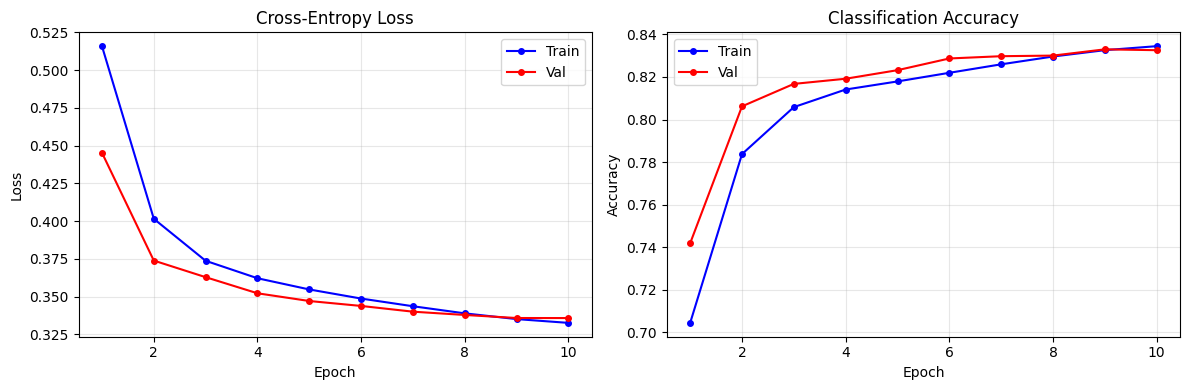

In [ ]:
# Plot training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
epochs = range(1, NUM_EPOCHS + 1)

ax1.plot(epochs, train_losses, 'b-o', label='Train', markersize=4)
ax1.plot(epochs, val_losses, 'r-o', label='Val', markersize=4)
ax1.set(xlabel='Epoch', ylabel='Loss', title='Cross-Entropy Loss')
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(epochs, train_accs, 'b-o', label='Train', markersize=4)
ax2.plot(epochs, val_accs, 'r-o', label='Val', markersize=4)
ax2.set(xlabel='Epoch', ylabel='Accuracy', title='Classification Accuracy')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Save Checkpoint

In [ ]:
checkpoint = {
    'params': jax.device_get(state.params),
    'config': {
        'distance': DISTANCE,
        'seq_len': seq_len,
        'd_model': 64,
        'num_heads': 4,
        'num_layers': 4,
        'ffn_dim': 256,
    },
}
path = f'transformer_qec_d{DISTANCE}.pkl'
with open(path, 'wb') as f:
    pickle.dump(checkpoint, f)
print(f'Saved: {path}')

Saved: transformer_qec_d3.pkl


## Next Steps

- Train for d=3 and d=7 by changing `DISTANCE` above and re-running.
- Proceed to **03_evaluation.ipynb** for MWPM comparison and threshold analysis.
- Experiment with model size, learning rate, or training noise rates.